# 🏠 House Price Analysis & Prediction

This project explores housing data and builds machine learning models to predict house prices based on key features such as income, location, and housing characteristics.

In [81]:
# Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 📥 Load Dataset

We load the King County housing dataset, which contains various features related to house prices.

In [82]:
# Load data 
df = pd.read_csv('kc_house_data.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### 🔍 Data Overview

We explore the dataset structure, data types, and summary statistics to understand the data before processing.

In [83]:
# Exploratory Data Analysis
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

#### 🧹 Data Cleaning 
We handle missing values and ensure the dataset is clean and ready for analysis.

In [84]:
# Data Cleaning and Feature Engineering
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']


#### ⚙️ Feature Engineering

We create new features to improve model performance, such as:
- Rooms per household  
- Bedrooms per room  
- Population per household

In [85]:
# Convert categorical to numeric FIRST
df = pd.get_dummies(df, drop_first=True)

In [86]:
# Then define X and y
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']


#### 🎯 Feature Selection

We separate the dataset into:
- Features (X)  
- Target variable (y: house price)

#### 🔀 Train-Test Split

We split the data into training and testing sets:
- 80% for training  
- 20% for testing  

This allows us to evaluate model performance on unseen data.

In [87]:
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 🤖 Model Training

In this section, we train machine learning models to predict house prices.

We use:
- Linear Regression as a baseline model  
- Random Forest Regressor for improved performance

#### 🤖 Linear Regression Model

We train a Linear Regression model as a baseline for predicting house prices.

In [88]:
# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 📉 Model Evaluation

We evaluate model performance using:

- RMSE (Root Mean Squared Error) → measures prediction error  
- R² Score → measures how well the model explains the data

In [89]:
# Evaluate model
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 5280716470.094011
R^2 Score: 0.5970176824350766


#### 🌳 Random Forest Model Evaluation

We evaluate the Random Forest model using RMSE and R² Score to measure prediction accuracy and error.

In [90]:
# Improve Random Forest label
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Python 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_rf = rf_model.predict(X_test)

print("🌳 Random Forest Model Evaluation")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")

🌳 Random Forest Model Evaluation
RMSE: 50111.94
R² Score: 0.8084


#### 📊 Data Visualization Advanced Model Insights

We analyze model performance using:

- Feature Importance → identifies key predictors  
- Actual vs Predicted → evaluates prediction accuracy  
- Error Distribution → analyzes prediction errors

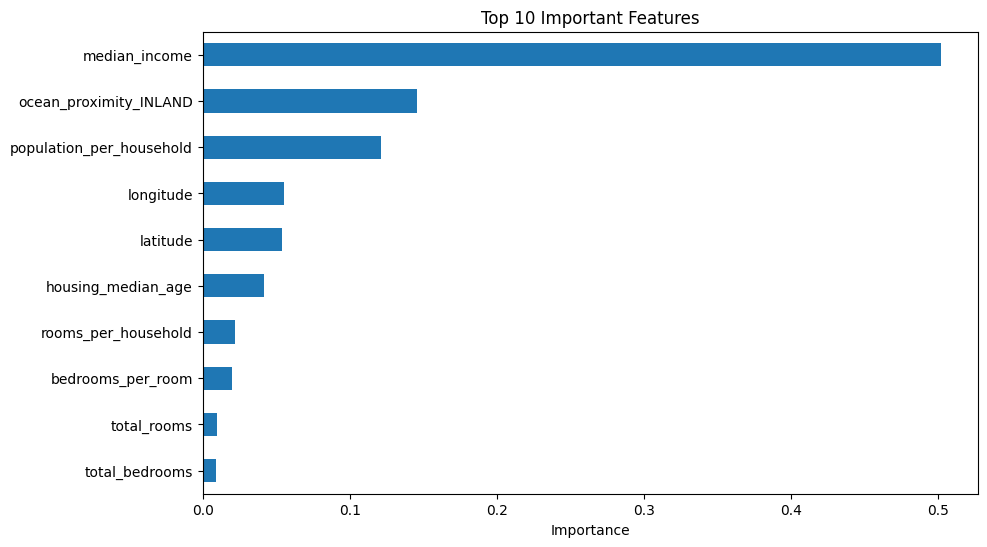

In [91]:
# Feature importance visualization
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.savefig("feature_importance.png")   # 👈 ADD THIS
plt.show()

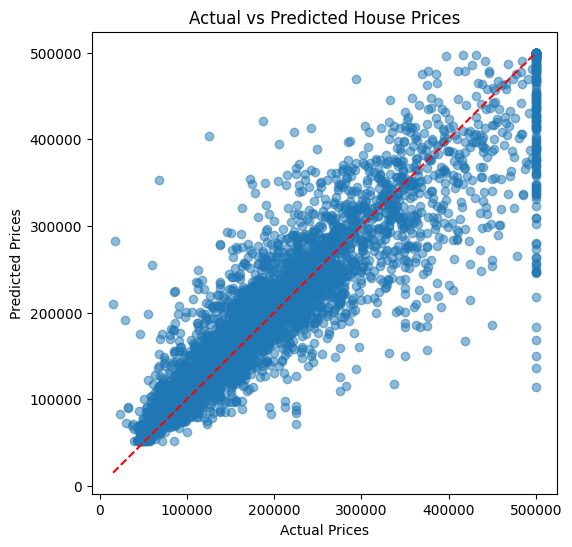

In [92]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.savefig("actual_vs_predicted.png")   # 👈 ADD THIS
plt.show()

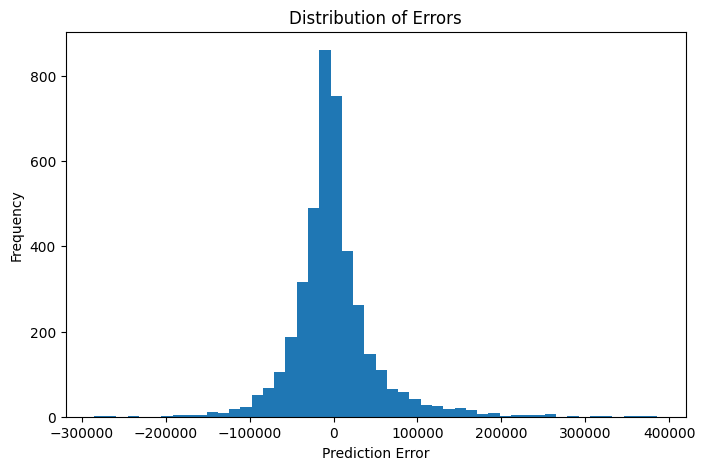

In [93]:
plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Distribution of Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.savefig("error_distribution.png")   # 👈 ADD THIS
plt.show()

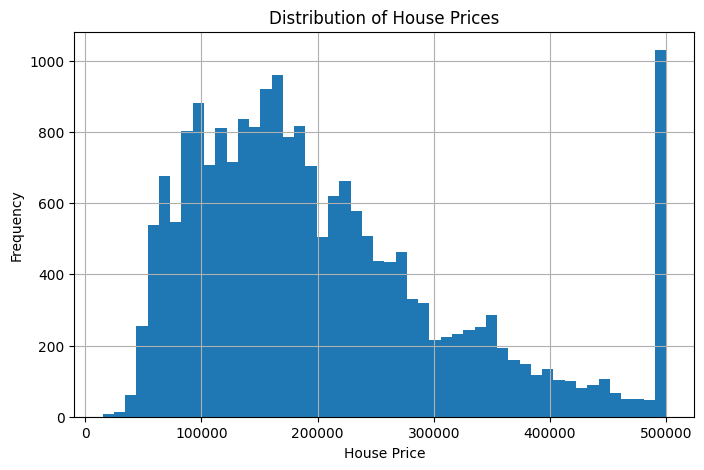

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['median_house_value'].hist(bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig("histogram_house_prices.png")  # SAVE IMAGE
plt.show()

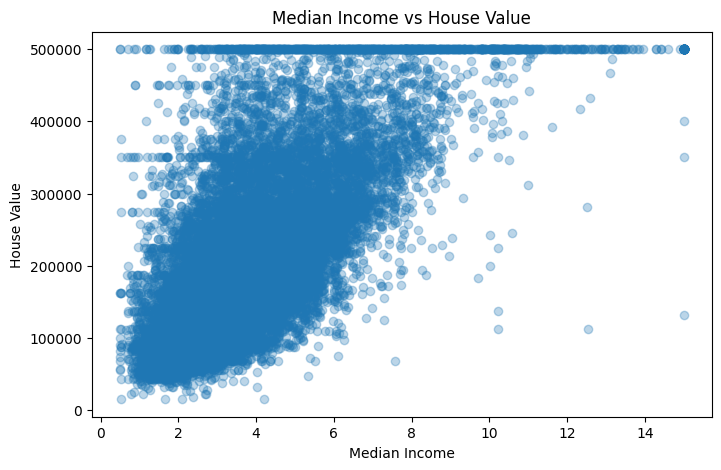

In [95]:
plt.figure(figsize=(8,5))

plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)

plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.savefig("scatter_income_vs_price.png")  # SAVE IMAGE
plt.show()

This scatter plot a positive relationship between median income and median house value. Areas with higher income tend to have higher housing prices.

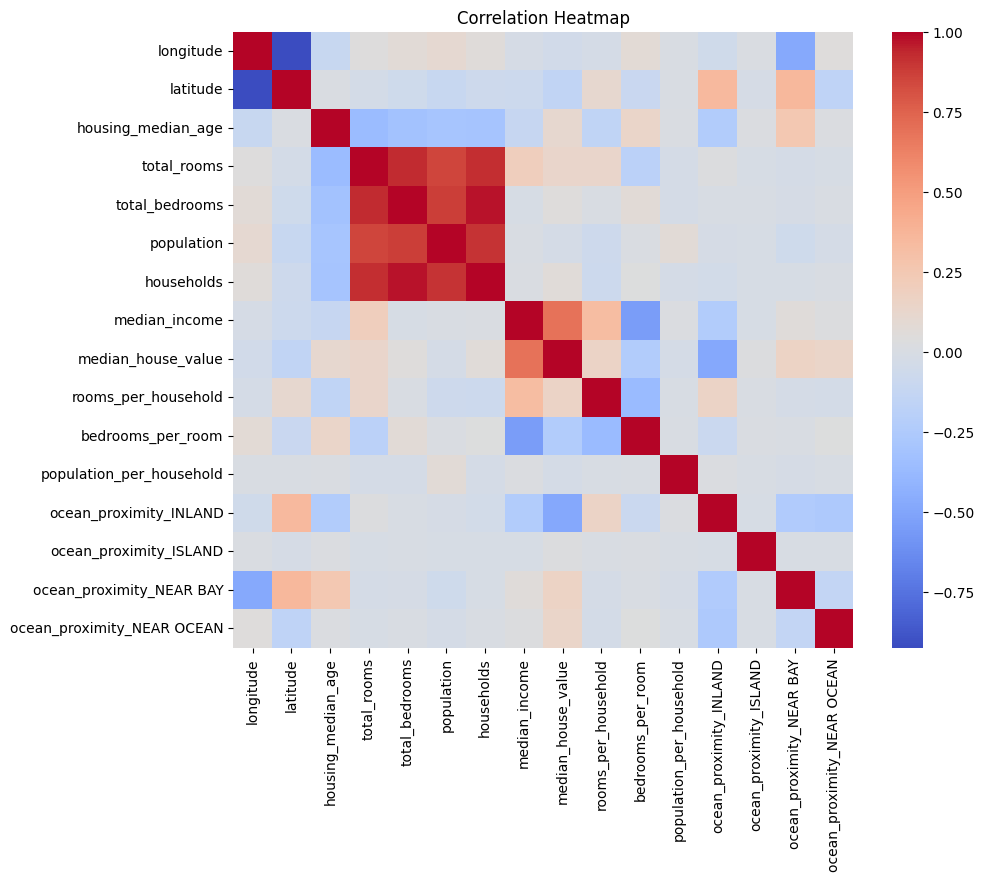

In [96]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("heatmap_correlation.png")  # SAVE IMAGE
plt.show()

## 🏁 Conclusion

The Random Forest model achieved the best performance with an R² score of approximately 0.81, significantly outperforming Linear Regression.

This indicates that the model explains over 80% of the variation in house prices.

Feature engineering and model selection played a crucial role in improving prediction accuracy.

Overall, this project demonstrates a complete machine learning workflow from data preprocessing to model evaluation.